# HHL — Demo

Walks through `algorithms.hhl` end to end: solve a 2x2 linear system
`Ax = b` for `A = a*I + b*X`, using quantum phase estimation to estimate
`A`'s eigenvalues, a multiplexed rotation to encode `1/lambda`, and
postselection on an ancilla qubit to recover (a state proportional to)
the solution `x`.

See [../math.md](../math.md) for the theory — including why HHL's success
is postselected rather than guaranteed, a fundamentally different shape
from every other algorithm in this repo — and [../paper.md](../paper.md)
for the circuit derivation this notebook exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
import math

import numpy as np
from qiskit.circuit import QuantumCircuit

from algorithms.hhl import visualization
from algorithms.hhl.circuit import build_hhl_circuit
from algorithms.hhl.execution import AerExecutor
from algorithms.hhl.implementation import solve_linear_system
from algorithms.hhl.oracles import DiagonalXOracle

# A = I + (1/3)X (eigenvalues 4/3, 2/3), t chosen so both eigenvalues land
# on exact 3-bit binary fractions of 2*pi/t (see math.md).
a, b, t = 1.0, 1.0 / 3.0, 3 * math.pi / 8
n_clock = 3
c_constant = 0.5

oracle = DiagonalXOracle(a, b, t)
b_state_prep = QuantumCircuit(1)  # |b> = |0>
executor = AerExecutor()

print(f"A = [[{a}, {b}], [{b}, {a}]]")
print(f"eigenvalues: {a + b} (|+>), {a - b} (|->)")

A = [[1.0, 0.3333333333333333], [0.3333333333333333, 1.0]]
eigenvalues: 1.3333333333333333 (|+>), 0.6666666666666667 (|->)


## The circuit

State prep on the b-register, QPE onto the clock register, a multiplexed
rotation on the ancilla, then QPE's inverse to uncompute the clock
register — all before measuring the ancilla and the b-register.

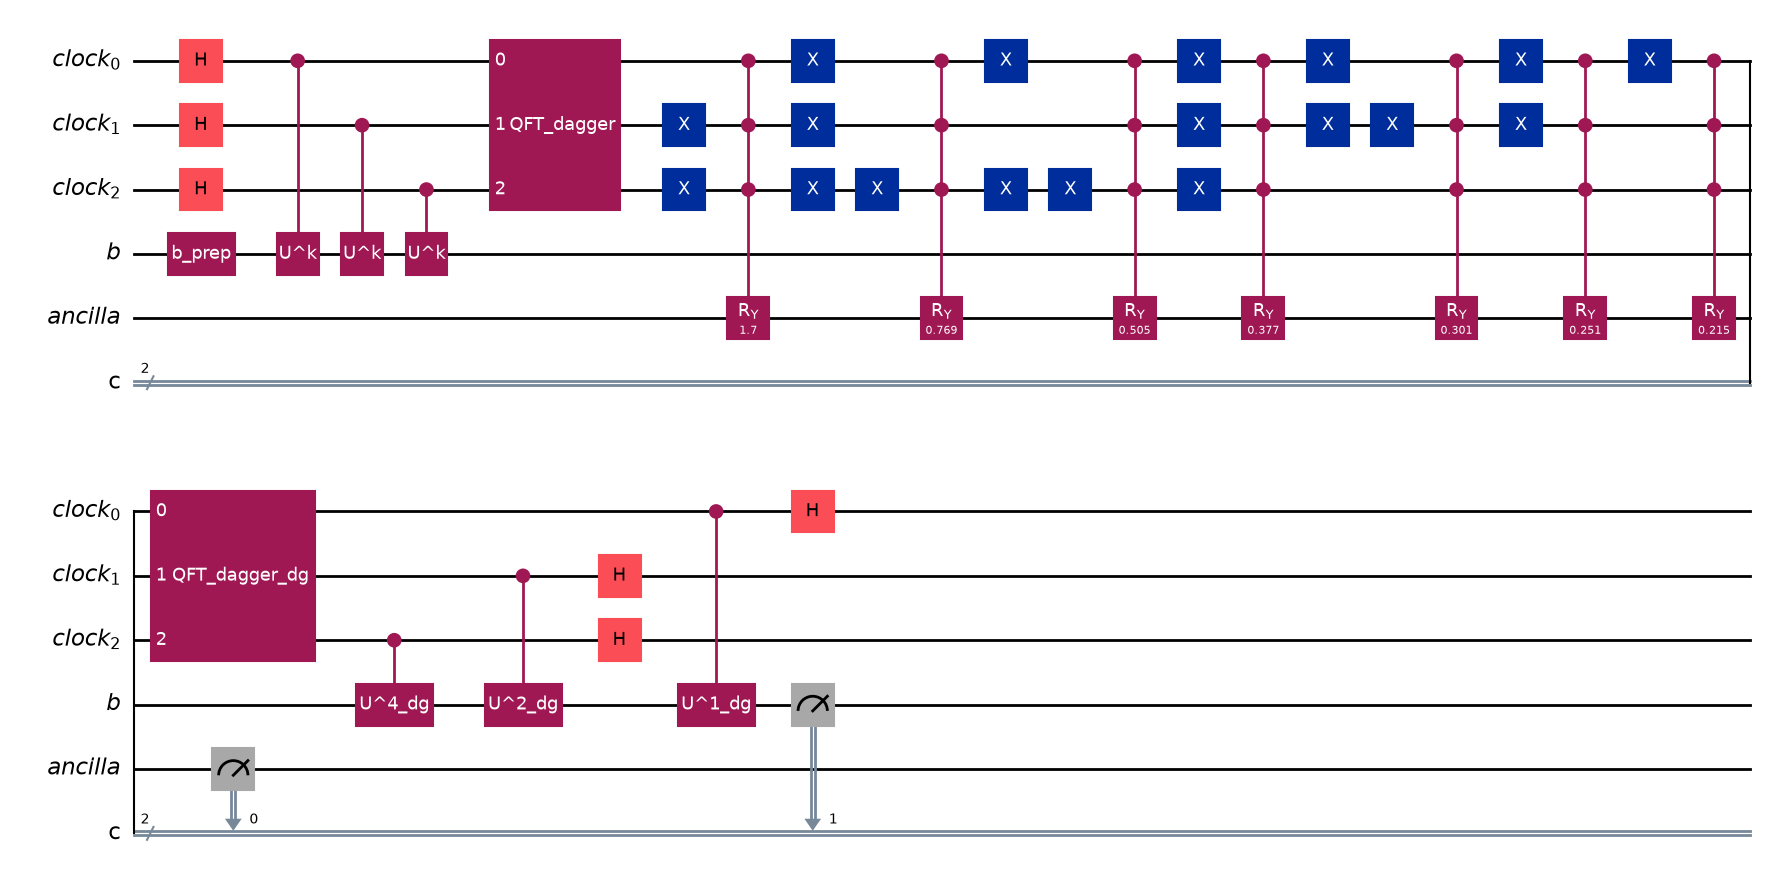

In [3]:
circuit = build_hhl_circuit(oracle, t, n_clock, c_constant, b_state_prep)
visualization.circuit_figure(circuit)

## Running it: postselected success

Measuring the ancilla as `1` signals a *usable* shot — the b-register is
then proportional to the solution `x`. Shots where the ancilla measures
`0` are discarded; this fraction is exactly `solve_linear_system`'s
reported success probability.

Success probability (ancilla == 1): 0.3460
b-register counts given ancilla == 1: {'0': 1242, '1': 142}


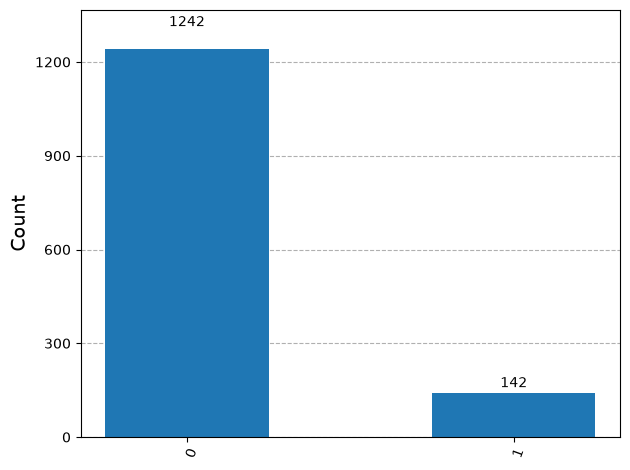

In [4]:
success_probability, b_counts = solve_linear_system(
    oracle, t, n_clock, c_constant, b_state_prep, executor=executor, shots=4000
)
print(f"Success probability (ancilla == 1): {success_probability:.4f}")
print(f"b-register counts given ancilla == 1: {b_counts}")
visualization.plot_measurement_histogram(b_counts)

## Checking against the classical solution

`numpy.linalg.solve` gives the exact classical answer for comparison —
feasible only because this system is small. The b-register's measured
distribution (conditioned on ancilla == 1) should match `|x|^2`,
normalized.

In [5]:
matrix_a = np.array([[a, b], [b, a]])
x = np.linalg.solve(matrix_a, np.array([1.0, 0.0]))
expected_probs = (x**2) / np.sum(x**2)
print(f"Classical solution x: {x}")
print(f"Expected |x|^2 (normalized): 0={expected_probs[0]:.4f}, 1={expected_probs[1]:.4f}")

total = sum(b_counts.values())
measured_probs = {bit: count / total for bit, count in b_counts.items()}
print(f"Measured probabilities: {measured_probs}")

assert abs(measured_probs.get("0", 0.0) - expected_probs[0]) < 0.05

Classical solution x: [ 1.125 -0.375]
Expected |x|^2 (normalized): 0=0.9000, 1=0.1000
Measured probabilities: {'0': 0.8973988439306358, '1': 0.10260115606936417}
